# Linear Regression From Scratch on Boston Housing Dataset

##Stages

1. Problem Formulation
2. EDA (look at the data, find problems)
3. Data Cleaning (fix the problems EDA found)
4. Feature Engineering
5. Train/Val/Test Split
6. Model Training
7. ModelEvaluation

## Stage 1: Problem Formulation
- **Target (Y):** `MEDV` — median house value in a neighborhood (in $1000s)
- **Features (X):** the remaining 13 columns (`CRIM` through `LSTAT`)


| Feature | Meaning |
|---|---|
| CRIM | Crime rate |
| ZN | Residential land proportion |
| INDUS | Industrial area proportion |
| CHAS | Charles River dummy variable |
| NOX | Nitric oxide concentration |
| RM | Average number of rooms |
| AGE | Proportion of old houses |
| DIS | Distance to employment centers |
| RAD | Highway accessibility |
| TAX | Property tax rate |
| PTRATIO | Pupil-teacher ratio |
| B | Demographic-related feature (ethically problematic — see Stage 4) |
| LSTAT | Lower status population percentage |

- **Unit of prediction:** one row = one neighborhood (not one single house)
- **Task type:** Regression — `MEDV` is a continuous number
- **Success metric:** decided later (Topic 12)
- **Note:** `B` column has a known ethical problem, handled in Feature Engineering



## Stage 2: Data Collection

The raw file uses spaces to separate values (not commas), and has no
column name row. loaded it with `sep=r'\s+'` and give it on my own
column names.

In [83]:
with open('/content/sample_data/housing.csv') as f:
  for _ in range (3):
    print(repr(f.readline()))

#data is space separated rather than comma separated also there  is no col name


' 0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00\n'
' 0.02731   0.00   7.070  0  0.4690  6.4210  78.90  4.9671   2  242.0  17.80 396.90   9.14  21.60\n'
' 0.02729   0.00   7.070  0  0.4690  7.1850  61.10  4.9671   2  242.0  17.80 392.83   4.03  34.70\n'


Data is space-separated.
No header row exists.

In [84]:
import pandas as pd

column_names = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD',
                 'TAX','PTRATIO','B','LSTAT','MEDV']

df = pd.read_csv(
    '/content/sample_data/housing.csv',
    sep=r'\s+',
    header=None,
    names=column_names
)

print(df.shape)
print(df.head())

(506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


## Stage 3: EDA (Exploratory Data Analysis)

EDA means looking at the data closely before modeling — checking its
structure, quality, and patterns so no hidden problems get missed.

**Steps:**
1. Shape and column types
2. Missing values check
3. Summary statistics (mean, min, max, etc.)
4. Outlier check (box plot)
5. Correlation with target
6. Distribution shape of target (histogram)
7. Correlation heatmap (all features vs each other)
8. Scatter plots for top 2 correlated features (RM, LSTAT)


Step 1: Shape and column types

Goal: check row/column count, and confirm every column is a number.

In [85]:
print(df.shape)
print(df.dtypes)

#each col has valid dtype ,there is no text or nan

(506, 14)
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object


506 rows and 14 cols
all cols are numeric nothing unexpected or problematic

Step 2: Missing values

Goal: check if any column has empty/missing entries.



In [86]:
print(df.isnull().sum())

#each feature/col has 0 missing or empty value

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


There is no missing value in any col

Step 3: Summary numbers

Goal: quick average/min/max snapshot of every column, to catch
anything that looks wrong.

0 price or -ve age

In [87]:
print(df.describe()) #statistics summary for each numerical col

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

- Every feature has 506 valyes ,no missing values
- CRIM - avg is bigger than median  - there are outliers - extrelmy high crime rates - avg become higher due to high values ( outliers)

- small std = values close together, large std = values spread out
- mean ≈ median generally means few/no outliers
- B feature: most values sit near the upper end , outliers are the *lower* values and are a smaller portion of the dataset — pulls the mean down ,no effect on median as such
- TAX and AGE show high variation; NOX, PTRATIO, RM are more consistent
- wildly different scales (TAX maxes at 711, NOX at 0.87) → makes gradient descent's loss surface elongated instead of round, causing zig-zagging → fix with feature scaling later


Step 4: Outliers (box plot)

goal : to decide wether the outlier is data entry mistake or a rare real value and to decide wether to rmove it or keep it

Outliers : Value much bigger or smaller than rest

boxplo:
- Q1–Q3 = the box,
whiskers = normal range beyond the box,
dots beyond whiskers = outliers.
- Tall box = values vary a lot, - short box = similar values, - - many dots = many outliers.





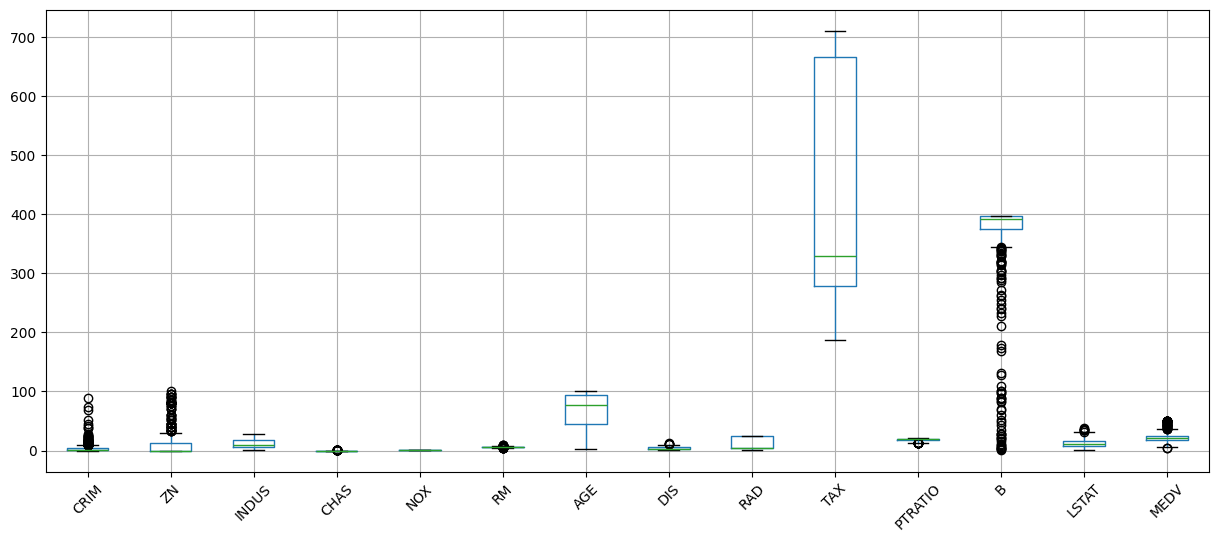

In [88]:
import matplotlib.pyplot as plt

df.boxplot(figsize =(15,6))
plt.xticks(rotation = 45)
plt.show()

What I found ⁉

- CRIM: small box, many outlier dots above - most areas low crime, a few extremely high
- ZN: small box, many outliers - most houses have little/no residential land, a few have a lot
- INDUS: no extreme values
- CHAS: tiny box - only 0 or 1 possible, little variation by nature
- NOX: small box, fairly similar across observations
- RM: small box, few outliers - most houses have a similar room count
- AGE: no major outliers, wide natural spread (old to new houses)
- B: many outliers
- MEDV, LSTAT: few outliers

Overall: CRIM, ZN, B, LSTAT, MEDV show outliers. TAX and AGE have wide spread (high variability). NOX and PTRATIO are narrow/consistent.



--Step 5: Correlation with target

Correlation:
ranges between - 1 to +1

-1 - neg correlation

0 - no linear relation

+1 - pos correlation  

corr tells which features are most useful to predict target


Pearson Correlation

Goal: which features move together with price (MEDV) the most ,
positively or negatively?

In [89]:
#df.corr() gives relation with every pair but for now we only want relation all var with MEDV -price only which is target

correlation = df.corr() ['MEDV'].sort_values(ascending = False)
print(correlation)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


What I found:
- MEDV correkates 1.0 with itself - expected,always true

- Strongest POSITIVE correlation with 'RM' (0.695) - more rooms per house, higher price.

- Strongest NEGATIVE correlation with LSTAT - higher percentage of lower status population drops the price of house in neighbourhood (opposite direction strongest relationship)
- CHAS not much related to price

A model should end up giving large weights to these two features with strongest correlation

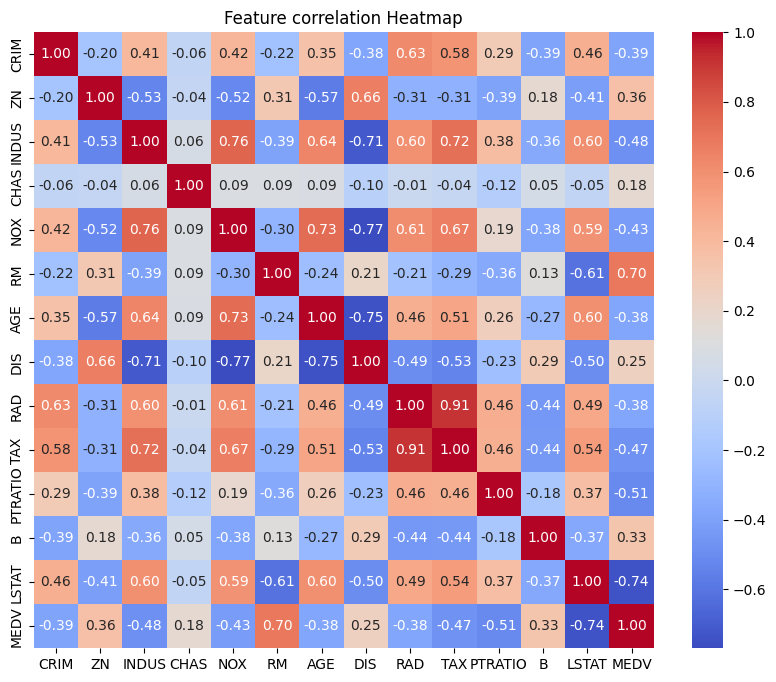

In [90]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot = True,fmt ='.2f',cmap ='coolwarm')
plt.title('Feature correlation Heatmap')
plt.show()

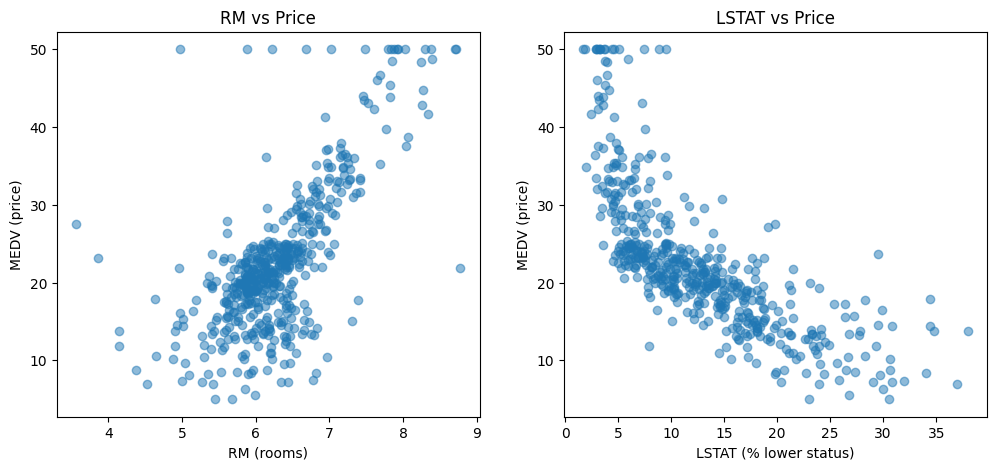

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(df['RM'], df['MEDV'], alpha=0.5)
axes[0].set_xlabel('RM (rooms)')
axes[0].set_ylabel('MEDV (price)')
axes[0].set_title('RM vs Price')

axes[1].scatter(df['LSTAT'], df['MEDV'], alpha=0.5)
axes[1].set_xlabel('LSTAT (% lower status)')
axes[1].set_ylabel('MEDV (price)')
axes[1].set_title('LSTAT vs Price')

plt.show()


RM has a positive impact on house prices, while LSTAT has a negative impact.

in LSTAT vs Price shape looks curve rether than straight line - linear regression will be limitation here we will need non linear model

step 6: Distribution Shape

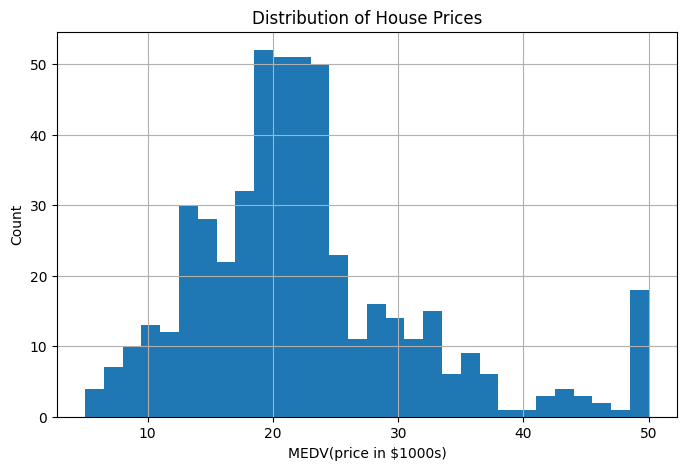

In [92]:
df['MEDV'].hist(bins = 30,figsize =(8,5))
plt.xlabel('MEDV(price in $1000s)')
plt.ylabel('Count')
plt.title('Distribution of House Prices')
plt.show()

#we will see how often certain range of values(price)shows up

What I found:

- Most neighbourhoods have prices between 15 to 25k ,peak at 20 to 22 k - this is normal middle of data

- bell shaped curve but not symmetric , more towards high price

- isolated spike at $50k  
   from describe() real prices above $50k were capped/recorded as 50 in dataset

   there are some capped rows at MEDV = 50 ,these are not real prices. So model trained on them will try to fit noise/artifical data at top end. We will either drop rows or give separate consideration - decide in feature Engineering

   

#Stage 4: Feature Engineering
(Decisions)

1. Drop 'B' col - not a legitimate feature
 - why ⁉ B is just mathematical transformation of race (black people) not directly related to house pricing

2. Drop rows where MEDV = 50 - these are not real prices (histogram spike)
  why ? from dataset docs 50 or above prices are capped at 50 so max = 50 is not just 50 it is 50 or more so they might not be real values  



In [93]:
df_clean = df.drop(columns = ['B'])
df_clean = df_clean[df_clean['MEDV'] != 50]
print(df_clean.shape)

(490, 13)


#Stage 5 : Train/Val/Test Split

In [94]:
from sklearn.model_selection import train_test_split

X= df_clean.drop(columns = ['MEDV']).values
#values converts pandas df into plain np array
#as df has col names attacthed and gd reuires array
y= df_clean['MEDV'].values.reshape(-1,1)
#reshape is making flat (N,) into (N,1) to match X 2d dim




X_train,X_temp,y_train,y_temp = train_test_split(X,y,test_size = 0.3,random_state = 42)
X_val,X_test,y_val,y_test = train_test_split(X_temp,y_temp,test_size = 0.5,random_state = 42)


print(X_train.shape,X_val.shape,X_test.shape)
print(y_train.shape,y_val.shape,y_test.shape)

(343, 12) (73, 12) (74, 12)
(343, 1) (73, 1) (74, 1)


Stage 5b — Feature Scaling -speeds convergence avoids elongated contours

(fit on train only) - Leakage safe pattern

In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Stage 6: Model Training , sklearn LinearRegression

In [96]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled,y_train)

LinearRegression()

In [97]:
print("sklearn weights:",model.coef_)
print('sklearn bias:',model.intercept_)

sklearn weights: [[-1.17798949  0.93978507 -0.37999681  0.02614657 -1.74770111  2.20299957
  -0.59711388 -3.00836424  1.9286005  -2.13934714 -1.83414472 -2.80532514]]
sklearn bias: [22.14198251]


**What the trained weights show:**
- RM has a large positive weight , matches EDA (strongest positive
  correlation with price)
- LSTAT has the largest weight overall - matches EDA (strongest
  correlation of any feature)
- DIS has a large NEGATIVE weight (-3.01), despite a weak +0.25
  correlation with price in EDA , the model learned the opposite sign
  of what raw correlation suggested. This is multicollinearity: DIS is
  strongly tied to NOX/AGE/INDUS, so once those are accounted for,
  DIS's own isolated effect differs from its raw pairwise correlation.

#Stage 7 : Model Evaluation

MAE
MSE
RMSE
R^2

Evaluate the model on the validation set because it contains unseen data and helps us check whether the model learned general patterns instead of just memorizing the training data.

The test set is not used during evaluation/tuning because it should be kept completely untouched until the end, where it gives the final unbiased estimate of the model's real-world performance.

In [98]:
import numpy as np
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

y_pred_val = model.predict(X_val_scaled)

mae_val = mean_absolute_error(y_val,y_pred_val)
mse_val = mean_squared_error(y_val,y_pred_val)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_val,y_pred_val)

print("Validation MAE:", mae_val)
print("Validation MSE:", mse_val)
print("Validation RMSE:", rmse_val)
print("Validation R²:", r2_val)


Validation MAE: 2.82174056711643
Validation MSE: 14.22897375349613
Validation RMSE: 3.7721311951595915
Validation R²: 0.7114017908053292


**Results (sklearn):**
- MAE = 2.82 - on average, predictions are off by about $2,820
- MSE = 14.23 - squared-error version, not directly interpretable in dollars
- RMSE = 3.77 - about $3,770 average difference between predicted and
  actual price, punishes larger misses more than MAE
- R² = 0.711 - the model explains about 71.1% of the variation in house
  price that guessing the average price for everyone would have missed